# EDA checklist (items + train)

- **Load + sanity:** shapes, dtypes, memory, head(); validate keys (`items.pid` unique, `train.lineID` unique).
- **Data quality:** missing % per column, duplicates, range/allowed-values checks; verify exactly one of `click/basket/order` = 1.
- **Items EDA:** top categories/manufacturers/groups; `rrp` distribution + outliers; inspect/parse `content`, check `genericProduct` share.
- **Train EDA:** action rates; `price/competitorPrice/revenue` distributions + outliers; `availability` + `adFlag`; trends by `day`.
- **Merge:** join `train`↔`items`; % unmatched `pid`; re-check missingness after merge.
- **Target (order):** compare `order=1` vs `0`; analyze `price_gap = price - competitorPrice` and `discount = price/rrp` vs order rate.
- **Notes:** flag leakage (e.g., `revenue`); write top insights + feature ideas.

## Ideas:
- to predict what product is being bought we should look into Price competitiveness and availablity:
    - discount_to_rrp = (rrp - price) / rrp
    - price_to_comp = price / competitorPrice (or comp_pct_diff; pick one)
    - is_cheaper_than_comp = price < competitorPrice
    - comp_missing = isna(competitorPrice) (missingness is often informative)
    - availability_bucket = treat availability as categorical (1/2/3/4)
    - ad_x_discount = adFlag * discount_to_rrp (ads convert differently when discounted)
    - day_of_week = day % 7 (captures weekly cycle if days are consecutive)
    - daily_cvr = (sum(order) by day) / (sum(click) by day) (merged back to rows; handle 0 clicks)
    - pid_expanding_cvr = historical conversion rate by pid up to previous days (time-safe expanding mean)
    - category_expanding_cvr = historical conversion rate by category up to previous days (helps for sparse pids)
---
- to predict quantity to take only order=1 rows from dataset and train it on target feature -> computed quantity that we find out based on price and revenue basis

## Load Libraries

In [1]:
# Core
import numpy as np
import pandas as pd

# Plots
import matplotlib.pyplot as plt
# Optional but nice for EDA (comment out if not installed)
import seaborn as sns

# Display / convenience
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 80)

# Reproducibility
np.random.seed(42)

# Inspect Datasets

## Items.csv

In [2]:
items = pd.read_csv("../../data/raw/items.csv", sep="|")
# Sanity overview
print("shape:", items.shape)
print(items.info())

shape: (22035, 11)
<class 'pandas.DataFrame'>
RangeIndex: 22035 entries, 0 to 22034
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pid             22035 non-null  int64  
 1   manufacturer    22035 non-null  int64  
 2   group           22035 non-null  str    
 3   content         22035 non-null  str    
 4   unit            22035 non-null  str    
 5   pharmForm       19708 non-null  str    
 6   genericProduct  22035 non-null  int64  
 7   salesIndex      22035 non-null  int64  
 8   category        17408 non-null  float64
 9   campaignIndex   1338 non-null   str    
 10  rrp             22035 non-null  float64
dtypes: float64(2), int64(4), str(5)
memory usage: 1.8 MB
None


In [3]:
print(items.describe())

                pid  manufacturer  genericProduct    salesIndex      category           rrp
count  22035.000000  22035.000000    22035.000000  22035.000000  17408.000000  22035.000000
mean   11018.000000    222.488042        0.033674     48.367461    113.933996     17.861648
std     6361.100927    223.103100        0.180392      6.166422     93.823387     19.823213
min        1.000000      1.000000        0.000000     40.000000      1.000000      0.070000
25%     5509.500000     60.000000        0.000000     40.000000     35.000000      7.260000
50%    11018.000000    156.000000        0.000000     53.000000     90.000000     12.080000
75%    16526.500000    311.000000        0.000000     53.000000    169.000000     21.270000
max    22035.000000   1067.000000        1.000000     53.000000    409.000000    404.970000


There is nothing relevant from items at this point moving to train.csv

## train.csv

In [4]:
train = pd.read_csv("../../data/raw/train.csv", sep="|")
print(train.shape)
print(train.head())

(2756003, 11)
   lineID  day    pid  adFlag  availability  competitorPrice  click  basket  order  price  revenue
0       1    1   6570       0             2            14.60      1       0      0  16.89     0.00
1       2    1  14922       1             1             8.57      0       1      0   8.75     0.00
2       3    1  16382       0             1            14.77      0       1      0  16.06     0.00
3       4    1   1145       1             1             6.59      0       0      1   6.55     6.55
4       5    1   3394       0             1             4.39      0       0      1   4.14     4.14


### Missing values

In [5]:
row_missing_pct = train.isna().mean(axis=1) * 100
print(row_missing_pct.describe())

count    2.756003e+06
mean     3.321246e-01
std      1.705582e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.090909e+00
dtype: float64


In [6]:
missing_cols = (train.isna().mean() * 100).sort_values(ascending=False)
print(missing_cols[missing_cols > 0].to_frame("missing_%"))

                 missing_%
competitorPrice    3.65337


In [7]:
missing_counts = train.isna().sum().sort_values(ascending=False)
print(missing_counts[missing_counts > 0].to_frame("missing_count"))

                 missing_count
competitorPrice         100687


In [8]:
na_rows = train[train.isna().any(axis=1)]
print("rows with any NA:", na_rows.shape[0])

print(na_rows.head())

rows with any NA: 100687
    lineID  day    pid  adFlag  availability  competitorPrice  click  basket  order  price  revenue
14      15    1  21983       0             1              NaN      0       0      1  54.95    54.95
63      64    1  19317       0             1              NaN      0       1      0   3.82     0.00
64      65    1   9482       0             1              NaN      1       0      0   3.34     0.00
82      83    1  19949       0             2              NaN      1       0      0  14.19     0.00
99     100    1   4232       0             1              NaN      0       1      0   7.65     0.00


If we train model to include competitorPrice we need to exclude these rows


### Integrity

check uniqueness of each row

In [9]:
print(train.columns)
print("lineID unique:", train["lineID"].is_unique)
print("duplicate lineID rows:", train.duplicated("lineID").sum())

Index(['lineID', 'day', 'pid', 'adFlag', 'availability', 'competitorPrice', 'click', 'basket', 'order', 'price',
       'revenue'],
      dtype='str')
lineID unique: True
duplicate lineID rows: 0


### Check One hot encoding for actions

In [10]:
action_sum = train[["click","basket","order"]].sum(axis=1)
print("rows where click/basket/order sum != 1:", (action_sum != 1).sum())
print(action_sum.value_counts().head())

rows where click/basket/order sum != 1: 0
1    2756003
Name: count, dtype: int64


### Basic Stats

In [11]:
# Numeric stats
print(train.describe(include=[np.number]).T)

                     count          mean            std   min        25%         50%         75%         max
lineID           2756003.0  1.378002e+06  795589.681306  1.00  689001.50  1378002.00  2067002.50  2756003.00
day              2756003.0  4.992118e+01      25.294512  1.00      31.00       50.00       71.00       92.00
pid              2756003.0  1.044790e+04    6456.012738  1.00    4313.00    10077.00    16144.00    22035.00
adFlag           2756003.0  3.177888e-01       0.465617  0.00       0.00        0.00        1.00        1.00
availability     2756003.0  1.111035e+00       0.392178  1.00       1.00        1.00        1.00        4.00
competitorPrice  2655316.0  1.277288e+01      12.752950  0.00       5.48        8.99       15.06      264.59
click            2756003.0  5.743198e-01       0.494446  0.00       0.00        1.00        1.00        1.00
basket           2756003.0  1.698423e-01       0.375494  0.00       0.00        0.00        0.00        1.00
order            27

### Base Events Rates

In [12]:
print("click rate:", train["click"].mean())
print("basket rate:", train["basket"].mean())
print("order rate:", train["order"].mean())

click rate: 0.574319766705624
basket rate: 0.16984234051994865
order rate: 0.2558378927744273


   day  click_rate  basket_rate  order_rate  avg_price   avg_comp      n
0    1    0.402005     0.245561    0.352435  12.846512  11.957254  18358
1    2    0.415787     0.236686    0.347528  12.902948  12.004867  17331
2    3    0.345981     0.256151    0.397868  12.275001  11.354881  24669
3    4    0.362985     0.244070    0.392945  12.841173  11.867855  24833
4    5    0.387293     0.247888    0.364819  12.790777  11.863600  26520


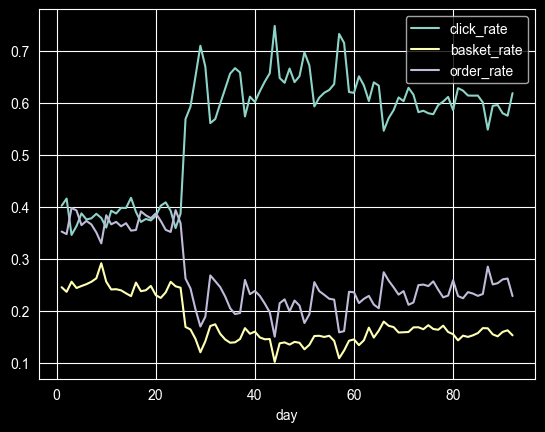

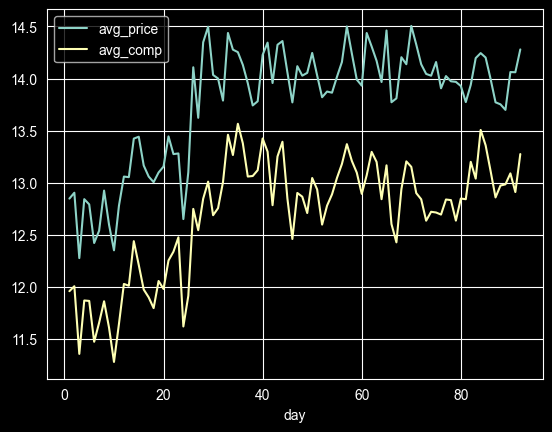

In [13]:
by_day = train.groupby("day").agg(
    click_rate=("click","mean"),
    basket_rate=("basket","mean"),
    order_rate=("order","mean"),
    avg_price=("price","mean"),
    avg_comp=("competitorPrice","mean"),
    n=("lineID","count")
).reset_index()

print(by_day.head())

by_day.plot(x="day", y=["click_rate","basket_rate","order_rate"])
plt.show()

by_day.plot(x="day", y=["avg_price","avg_comp"])
plt.show()

It seems that when there was a sudden price spike that affected everyone (the trend is seen in Avg. price ours vs competitor)
we started loosing sales. Hinting on that whatever justyfied our premium is not good enough in the situation of increased prices
and customers decided to switch to cheaper competitors.

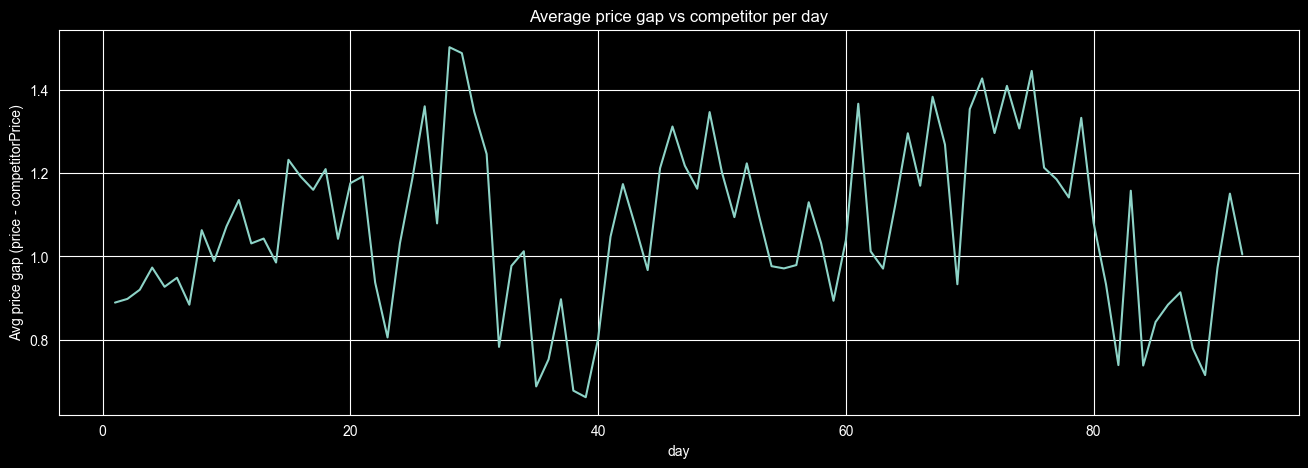

In [14]:
by_day = (
    train.groupby("day")
    .agg(
        avg_price=("price", "mean"),
        avg_comp=("competitorPrice", "mean"),  # ignores NaN
        n=("lineID", "count"),
        comp_missing_rate=("competitorPrice", lambda s: s.isna().mean() * 100),
    )
    .reset_index()
)

by_day["avg_gap"] = by_day["avg_price"] - by_day["avg_comp"]
by_day["avg_ratio"] = by_day["avg_price"] / by_day["avg_comp"]

# 1) Gap (CHF) per day
ax = by_day.plot(x="day", y="avg_gap", legend=False, figsize=(16, 5))
ax.set_ylabel("Avg price gap (price - competitorPrice)")
ax.set_title("Average price gap vs competitor per day")
plt.show()

# # 2) Optional: Ratio per day (e.g., 1.03 = 3% higher)
# ax = by_day.plot(x="day", y="avg_ratio", legend=False, figsize=(16, 5))
# ax.set_ylabel("Avg price ratio (price / competitorPrice)")
# ax.set_title("Average price ratio vs competitor per day")
# plt.show()

This is just to closely explore the development of the gap in price

### Check if every pid in train.csv correspond to item in items.csv

In [15]:
train_pids = set(train["pid"].unique())
items_pids = set(items["pid"].unique())

missing_in_items = train_pids - items_pids
print("Unique pids in train:", len(train_pids))
print("Unique pids in items:", len(items_pids))
print("Unique pids in train NOT in items:", len(missing_in_items))

# Optional: show a few missing pids
print("Example missing pids:", list(missing_in_items)[:10])

Unique pids in train: 21928
Unique pids in items: 22035
Unique pids in train NOT in items: 0
Example missing pids: []


now that I checked this I can move to check if we sel above or below rrp on average

first we need to add rrp from items into train df

In [16]:
items_rrp = items[["pid", "rrp"]].drop_duplicates("pid")
df = train.merge(items_rrp, on="pid", how="left")

print("Rows with missing rrp after merge:", df["rrp"].isna().sum())
print("Missing rrp %:", df["rrp"].isna().mean() * 100)

Rows with missing rrp after merge: 0
Missing rrp %: 0.0


create above/below rrp vs price

In [17]:
df["above_rrp_abs"] = df["price"] - df["rrp"]      # CHF above/below
df["above_rrp_pct"] = df["price"] / df["rrp"] - 1  # % above/below (e.g. 0.05 = +5%)

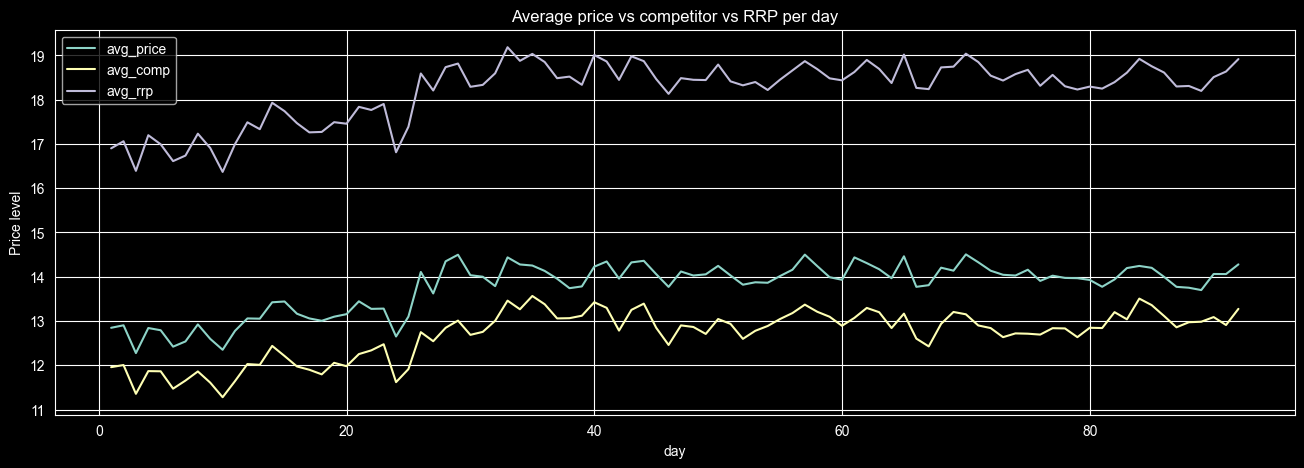

In [18]:
by_day = (
    df.groupby("day")
      .agg(
          avg_price=("price", "mean"),
          avg_comp=("competitorPrice", "mean"),  # ignores NaN automatically
          avg_rrp=("rrp", "mean"),
          avg_above_rrp_abs=("above_rrp_abs", "mean"),
          avg_above_rrp_pct=("above_rrp_pct", "mean"),
          n=("lineID", "count"),
      )
      .reset_index()
)

ax = by_day.plot(x="day", y=["avg_price", "avg_comp", "avg_rrp"], figsize=(16, 5))
ax.set_title("Average price vs competitor vs RRP per day")
ax.set_ylabel("Price level")
plt.show()

We can observe that we are cheap for the market on average. Our competitors are even cheaper and the sudden price spike was the tilting point for customers to go with the competitors.


This is not all saying. Next step is to look at these prices but for each product separately.

Also to look at event rate average per day to see if customers stopped finishid their orders, or even adding to basket, or even clicking ont he product...

### Heatmap Feature Correlation

In [20]:
data = train.copy()
features = ["adFlag", "availability", "competitorPrice", "click", "basket", "order", "price"]

corr_with_order = (
    data[features]
    .corr(numeric_only=True)["order"]
    .sort_values(ascending=False)
)

print(corr_with_order)

order              1.000000
adFlag             0.104110
competitorPrice   -0.076286
price             -0.080649
availability      -0.089054
basket            -0.265211
click             -0.681058
Name: order, dtype: float64


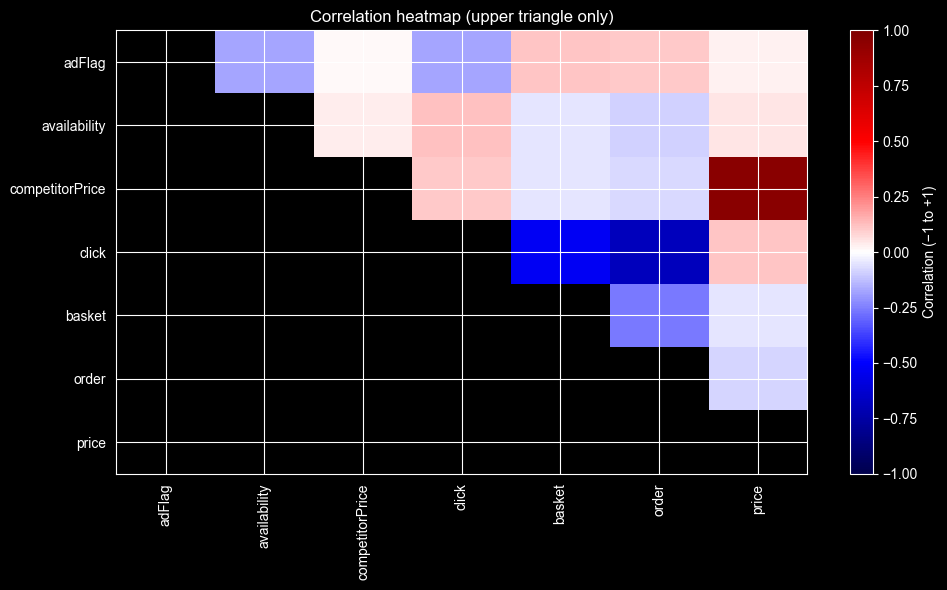

In [21]:
features = ["adFlag", "availability", "competitorPrice", "click", "basket", "order", "price"]

corr = data[features].corr(numeric_only=True)   # <- y_order cannot appear now

mask = np.tril(np.ones_like(corr, dtype=bool))  # hide lower + diagonal
corr_upper = corr.mask(mask)

plt.figure(figsize=(10, 6))
plt.imshow(corr_upper, aspect="auto", cmap="seismic", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(label="Correlation (−1 to +1)")
plt.title("Correlation heatmap (upper triangle only)")
plt.tight_layout()
plt.show()

## Expect Price

We look into the price for what the company sells the product.
Our goal is to split the whole dataset into several price categories
and then explore price swings and customer behaviour per category

True


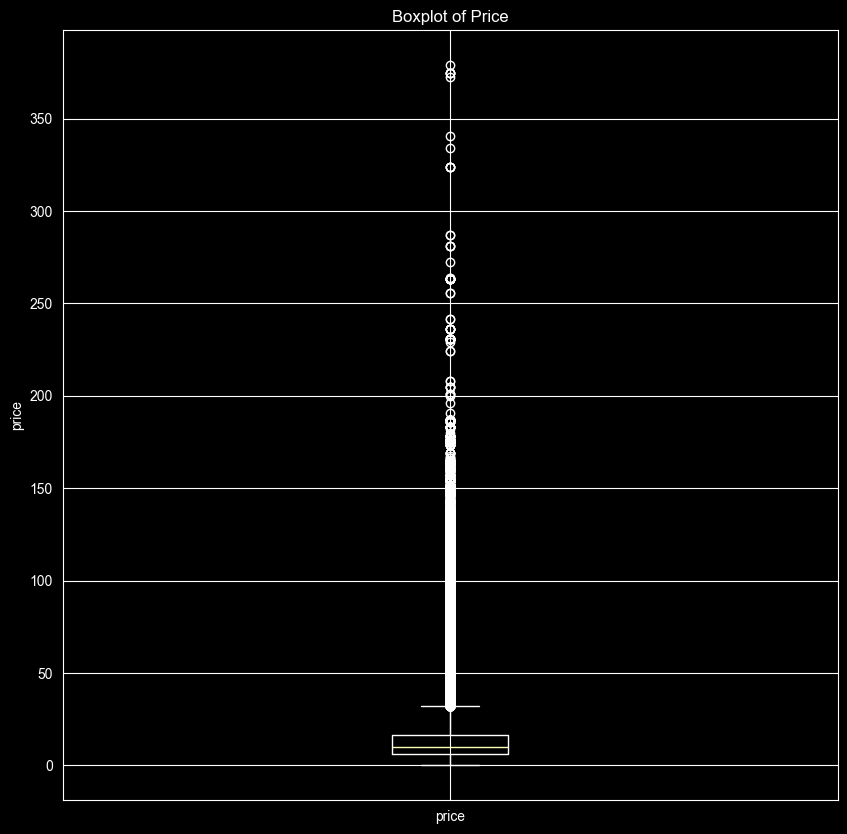

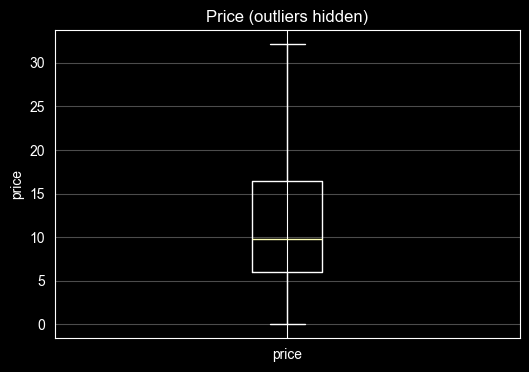

In [34]:
print((train["price"] < 1).any()) # saw wiskers going to zero so i was curious. used this to check if we have 0, negative or between 0 and 1 sdome prices (We have only between 0 and 1 & obviously higher as well)
plt.figure(figsize=(10, 10))
plt.boxplot(df["price"].dropna(), tick_labels=["price"])
plt.title("Boxplot of Price")
plt.ylabel("price")
plt.show()

plt.figure(figsize=(6,4))
plt.boxplot(train["price"].dropna(), tick_labels=["price"], showfliers=False)
plt.title("Price (outliers hidden)")
plt.ylabel("price")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### Def uts functions for next steps

In [43]:
# Define the func to investigate different numeric cols

def boxplot_stats(df: pd.DataFrame, col: str):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    if s.empty:
        raise ValueError(f"No numeric values in {col}")

    q1 = s.quantile(0.25)
    med = s.quantile(0.50)
    q3 = s.quantile(0.75)
    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    print(f"Column: {col}")
    print(f"n (non-NaN): {len(s)}   missing: {df[col].isna().sum()}")
    print(f"min:    {s.min():.6g}")
    print(f"Q1:     {q1:.6g}")
    print(f"mean:   {s.mean():.6g}")
    print(f"median: {med:.6g}")
    print(f"Q3:     {q3:.6g}")
    print(f"max:    {s.max():.6g}\n")

### Inspection starts

In [44]:
# to run this run func def part
boxplot_stats(train, "price")

boxplot_stats(train, "competitorPrice")

Column: price
n (non-NaN): 2756003   missing: 0
min:    0.02
Q1:     6
mean:   13.8501
median: 9.85
Q3:     16.45
max:    378.84

Column: competitorPrice
n (non-NaN): 2655316   missing: 100687
min:    0
Q1:     5.48
mean:   12.7729
median: 8.99
Q3:     15.06
max:    264.59



### Next text is my thoughts sumarized by AI

We observed that the price distribution is strongly right-skewed, so an overall average price masks very different regimes. In our data (n = 2,756,003), the median price is 9.85 while the mean is higher (13.85), indicating a long upper tail. The interquartile range spans Q1 = 6 to Q3 = 16.45, and Tukey’s 1.5·IQR rule places the upper outlier threshold at 32.125. About 204k rows lie above this threshold, meaning a non-trivial part of the dataset sits in a “high-price / outlier” region that can dominate aggregate statistics.

Because we want to understand behavioral differences (click/basket/order) and price sensitivity across price levels, we analyze the data by price category rather than relying on global averages. This lets us test whether customers react differently to price changes depending on whether an item is low-priced (potentially lower purchase friction), mid-priced (the typical purchase band), or high-priced (more considered decisions, potentially different competitive effects).

We therefore define price categories using distribution-anchored cut points: a dedicated bucket for very low prices, bins aligned to Q1, median, Q3, and the upper non-outlier boundary, and a final bin for the outlier tail. Concretely, we split prices into:

- 0–1
- 1–6 (below Q1)
- 6–9.85 (Q1 → median)
- 9.85–16.45 (median → Q3)
- 16.45–32.125 (Q3 → upper non-outlier threshold)
- 32.125 (high-price / outlier tail, up to max 378.84)

These bins are interpretable, reflect the empirical structure of the distribution, and support comparing drivers and price-response patterns across distinct price regimes.

In [45]:
# Adding the category column for exploration

bins = [-np.inf, 1, 6, 9.85, 16.45, 32.125, np.inf]

train["price_cat"] = pd.cut(
    train["price"],
    bins=bins,
    labels=[1, 2, 3, 4, 5, 6],
    right=False,
    include_lowest=True
).astype("int8")

### Now i plot the behavior rates + price per category

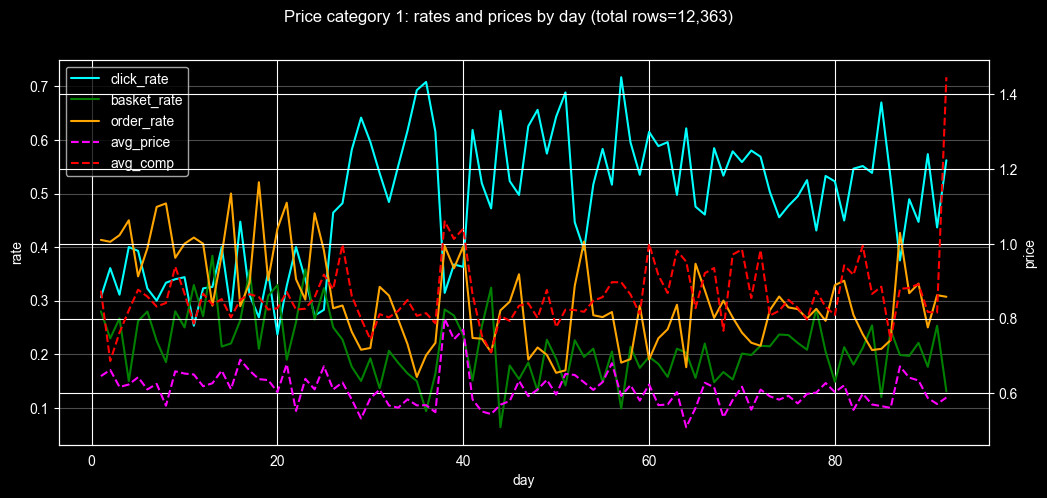

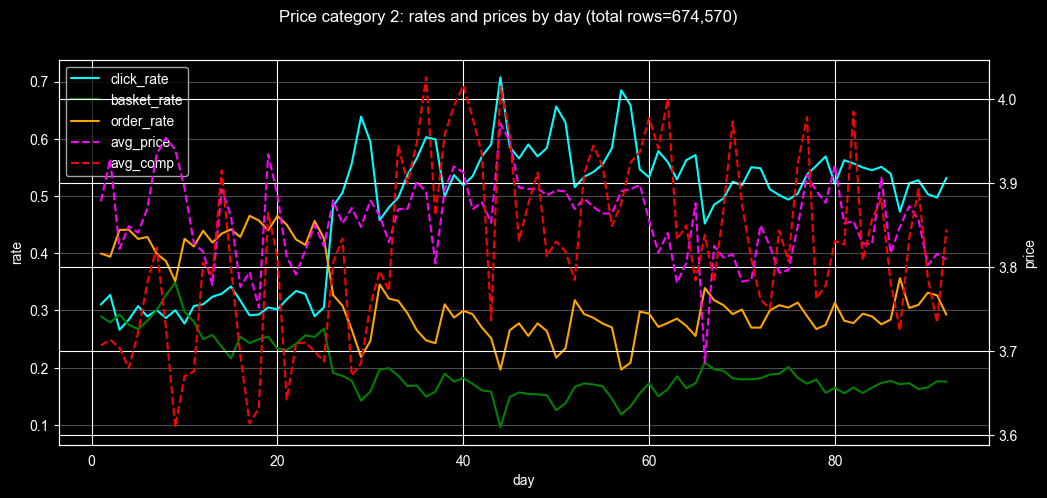

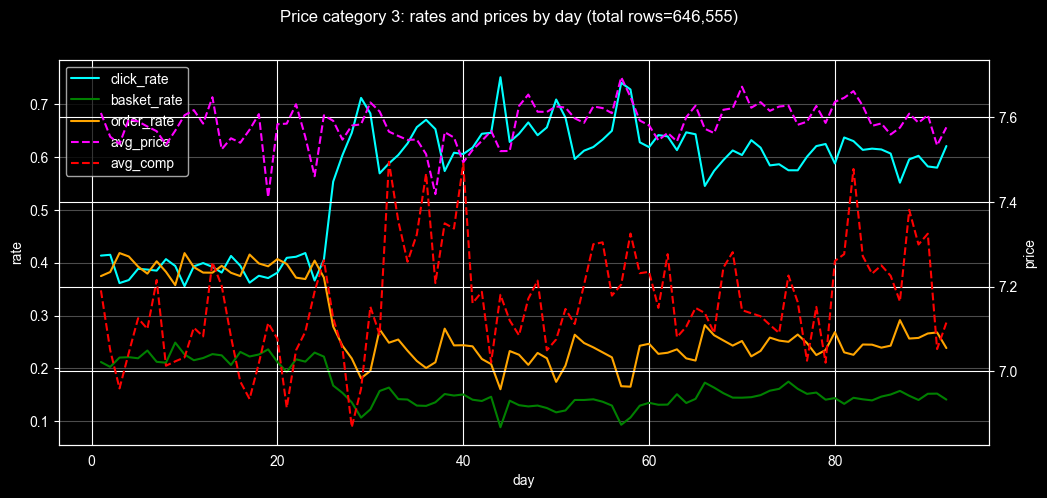

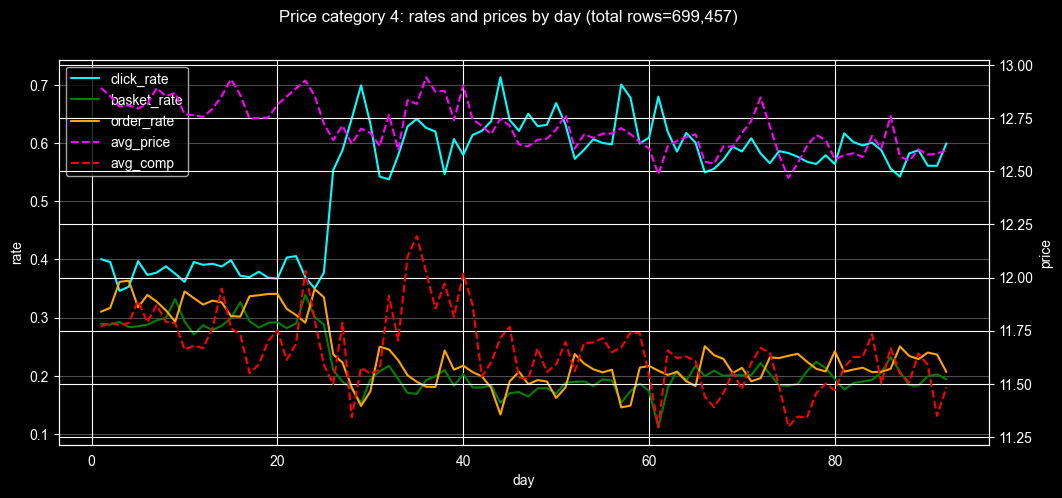

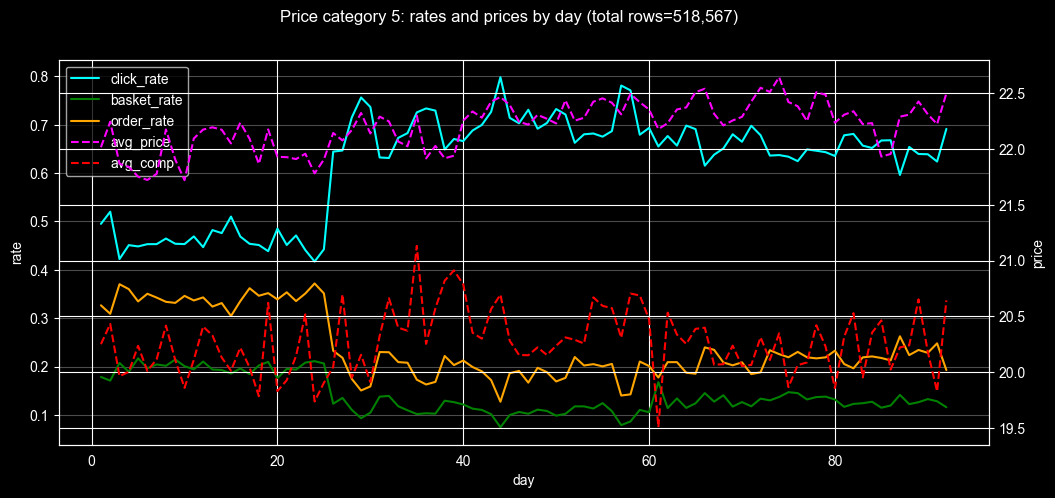

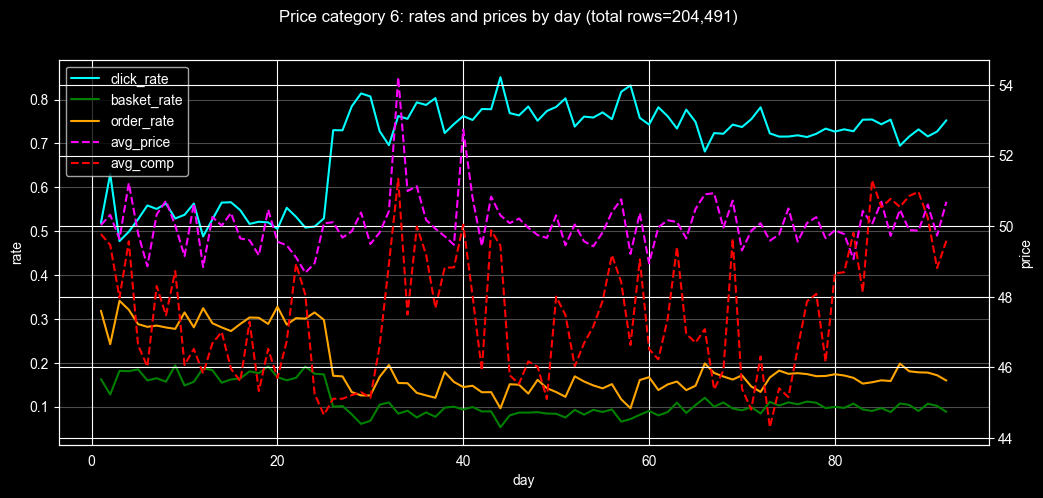

In [58]:
cat_col = "price_cat"

for cat, g in train.groupby(cat_col, sort=True):
    by_day = (
        g.groupby("day")
         .agg(
             click_rate=("click", "mean"),
             basket_rate=("basket", "mean"),
             order_rate=("order", "mean"),
             avg_price=("price", "mean"),
             avg_comp=("competitorPrice", "mean"),
             n=("lineID", "count"),
         )
         .reset_index()
         .sort_values("day")
    )

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # left axis: event rates
    by_day.plot(x="day", y=["click_rate", "basket_rate", "order_rate"],
                ax=ax1, color=["cyan", "green", "orange"])
    ax1.set_xlabel("day")
    ax1.set_ylabel("rate")
    ax1.grid(True, axis="y", alpha=0.3)

    # right axis: prices
    ax2 = ax1.twinx()
    by_day.plot(x="day", y=["avg_price", "avg_comp"],
                ax=ax2, linestyle="--", legend=False,
                color=["magenta", "red"])
    ax2.set_ylabel("price")

    # combine legends from both axes
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    fig.suptitle(f"Price category {cat}: rates and prices by day (total rows={by_day['n'].sum():,})")
    # plt.tight_layout()
    plt.show()

### conclusion

At this point I cannot see any patterns

I will check if we just dont have higher traffic of clickers

Edit: My observation was useless. We only have higher traffic on the page probably new customers looking on the products after a campain ergo. more clicks

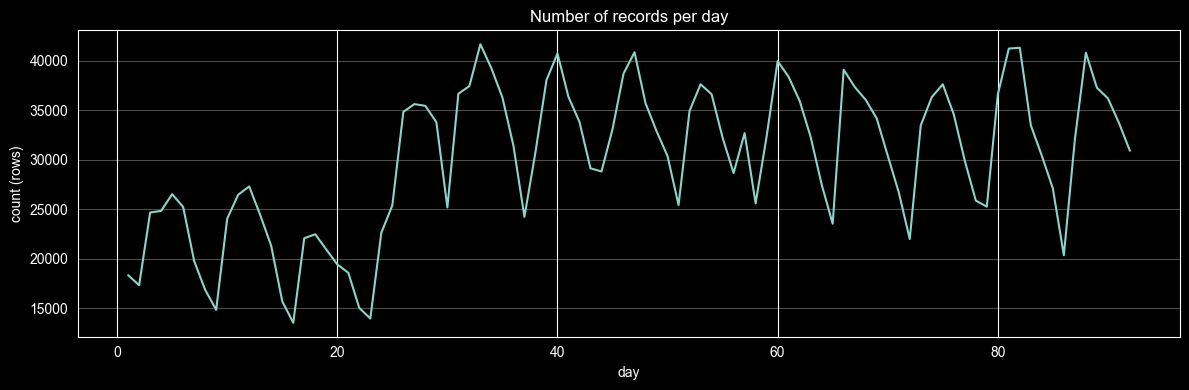

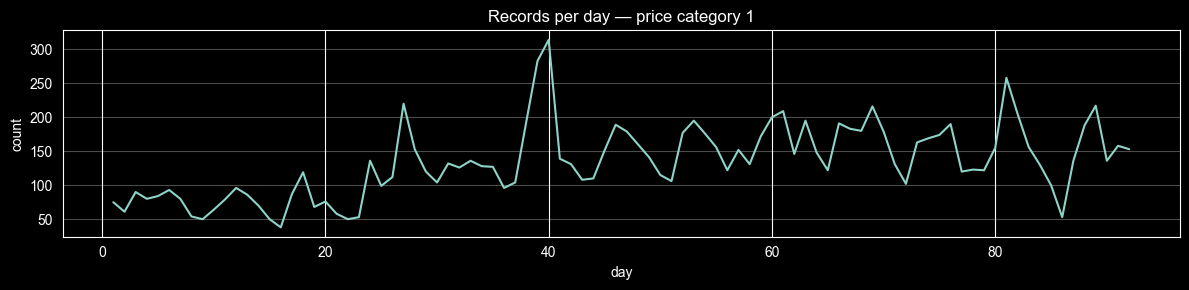

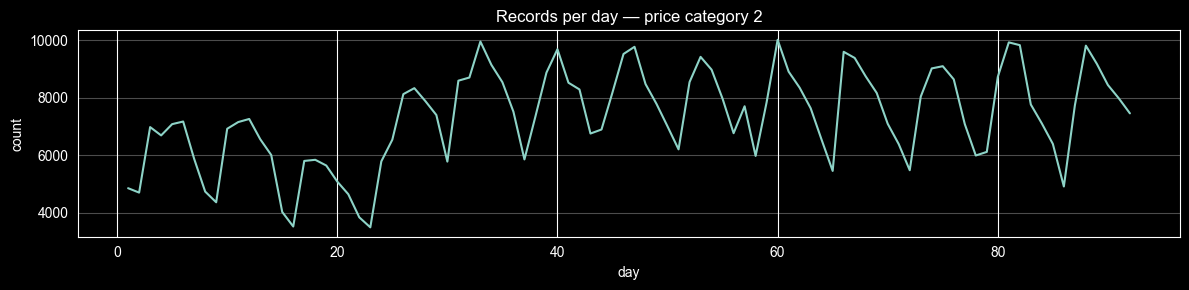

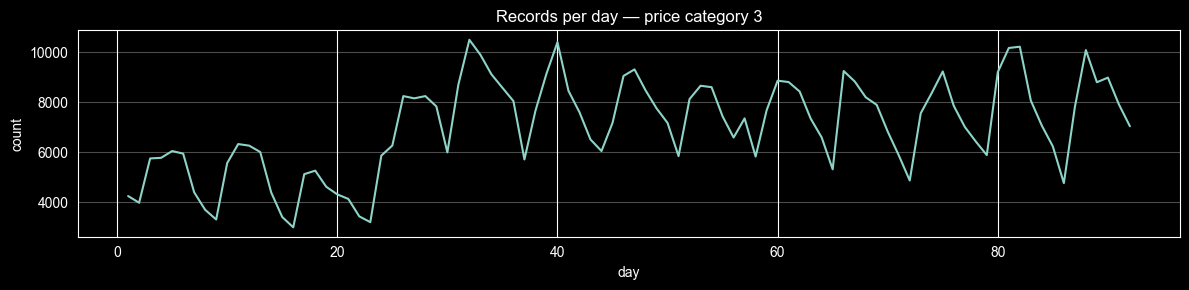

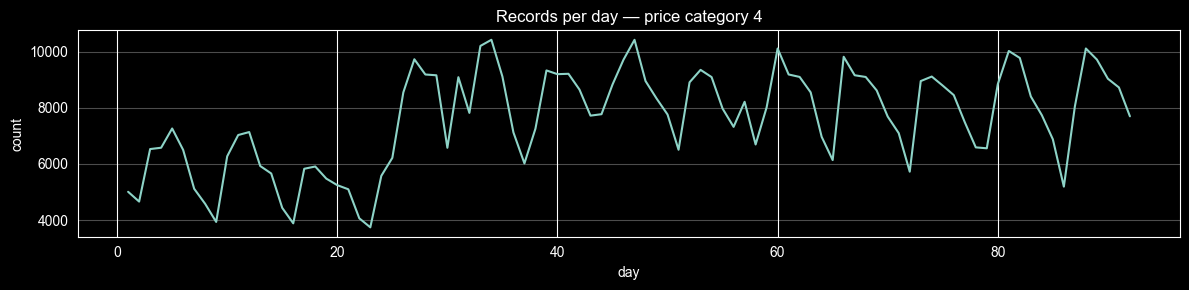

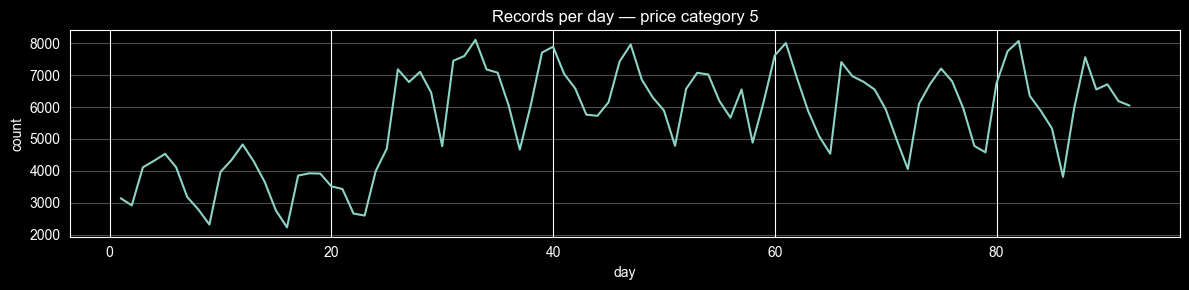

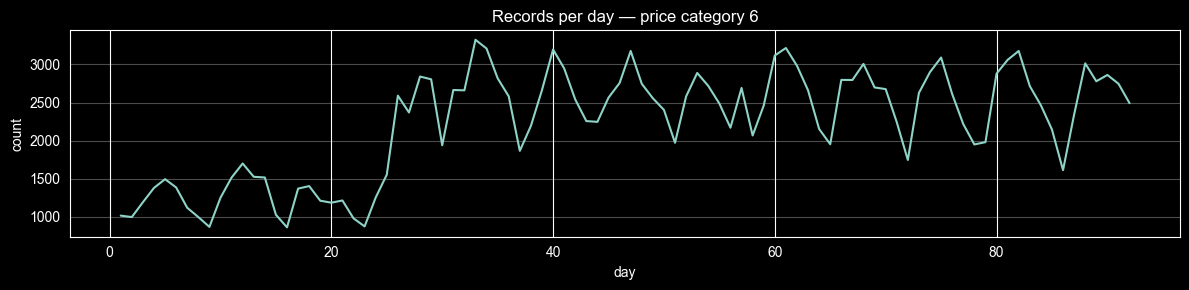

In [60]:
n_by_day = (
    train.groupby("day")
         .size()                  # counts rows regardless of NaNs
         .reset_index(name="n")
         .sort_values("day")
)

ax = n_by_day.plot(x="day", y="n", figsize=(12,4), legend=False)
ax.set_title("Number of records per day")
ax.set_xlabel("day")
ax.set_ylabel("count (rows)")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

n_by_day_cat = (
    train.groupby(["day", "price_cat"])
         .size()
         .reset_index(name="n")
         .sort_values(["price_cat","day"])
)

for cat, g in n_by_day_cat.groupby("price_cat", sort=True):
    ax = g.plot(x="day", y="n", figsize=(12,3), legend=False)
    ax.set_title(f"Records per day — price category {cat}")
    ax.set_xlabel("day")
    ax.set_ylabel("count")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## Repeat the same split analysis but group by "group" feature in items.csv